In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import datetime as dt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import plotly.express as px
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA


In [2]:
df = pd.read_excel("/kaggle/input/datasets/mohamedelmelegy10/online-retail/Online Retail.xlsx")

In [3]:
df['InvoiceNo'] = df['InvoiceNo'].astype(str)

df_clean = df[~df['InvoiceNo'].str.startswith('C')]
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['UnitPrice'] > 0]

print(f"Original Size: {len(df)}")
print(f"Size After Cleaning: {len(df_clean)}")

Original Size: 541909
Size After Cleaning: 530104


In [4]:
df_clean['Description'] = df_clean['Description'].fillna('Unknown Product')
df_clean = df.dropna(subset=['CustomerID'])
print("Missing values after cleanup:")
print(df_clean[['CustomerID', 'Description']].isnull().sum())
print(f"\nTotal rows remaining: {len(df_clean)}")

df_clean = df_clean[df_clean['CustomerID'] != 99999]

Missing values after cleanup:
CustomerID     0
Description    0
dtype: int64

Total rows remaining: 406829


In [5]:
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']
customer_clv = df_clean.groupby('CustomerID')['TotalPrice'].sum().reset_index()
customer_clv.columns = ['CustomerID', 'TotalSpending_CLV']
customer_clv = customer_clv.sort_values(by='TotalSpending_CLV', ascending=False)

In [6]:
snapshot_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                  # Frequency
    'TotalPrice': 'sum'                                      # Monetary
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

rfm = rfm[rfm['Monetary'] > 0]
print(rfm.head())

   CustomerID  Recency  Frequency  Monetary
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40
5     12352.0       36         11   1545.41


In [7]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

# 0 = Monday, 6 = Sunday
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.dayofweek
df_clean['DayName'] = df_clean['InvoiceDate'].dt.day_name() 

df_clean['Month'] = df_clean['InvoiceDate'].dt.month

#  (Season)
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df_clean['Season'] = df_clean['Month'].apply(get_season)

print(df_clean[['InvoiceDate', 'Hour', 'DayName', 'Month', 'Season']].head())

          InvoiceDate  Hour    DayName  Month  Season
0 2010-12-01 08:26:00     8  Wednesday     12  Winter
1 2010-12-01 08:26:00     8  Wednesday     12  Winter
2 2010-12-01 08:26:00     8  Wednesday     12  Winter
3 2010-12-01 08:26:00     8  Wednesday     12  Winter
4 2010-12-01 08:26:00     8  Wednesday     12  Winter


In [8]:
df_clean['Is_Vintage'] = df_clean['Description'].str.contains('VINTAGE').astype(int)
df_clean['Is_Set'] = df_clean['Description'].str.contains('SET').astype(int)
df_clean['Is_Retro'] = df_clean['Description'].str.contains('RETROSPOT').astype(int)
df_clean['Is_Heart'] = df_clean['Description'].str.contains('HEART').astype(int)

colors = ['RED', 'BLUE', 'GREEN', 'WHITE', 'PINK', 'SILVER', 'GOLD']

for color in colors:
    df_clean[f'Color_{color}'] = df_clean['Description'].str.contains(color).astype(int)

print(df_clean[['Description', 'Is_Vintage', 'Is_Set', 'Color_RED','Is_Retro','Is_Heart']].head())

                           Description  Is_Vintage  Is_Set  Color_RED  \
0   WHITE HANGING HEART T-LIGHT HOLDER           0       0          0   
1                  WHITE METAL LANTERN           0       0          0   
2       CREAM CUPID HEARTS COAT HANGER           0       0          0   
3  KNITTED UNION FLAG HOT WATER BOTTLE           0       0          0   
4       RED WOOLLY HOTTIE WHITE HEART.           0       0          1   

   Is_Retro  Is_Heart  
0         0         1  
1         0         0  
2         0         1  
3         0         0  
4         0         1  


In [9]:
from sklearn.preprocessing import StandardScaler

features = ['Recency', 'Frequency', 'Monetary']
rfm_data = rfm[features]
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_data)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=features)

print(rfm_scaled_df.head())

    Recency  Frequency  Monetary
0 -0.891260   0.200814  0.288849
1 -0.154795  -0.118900 -0.015280
2 -0.719755  -0.438615 -0.020084
3  2.216019  -0.438615 -0.192332
4 -0.548249   0.627100 -0.045760


In [10]:
Q1 = rfm['Monetary'].quantile(0.25)
Q3 = rfm['Monetary'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

rfm_clean = rfm[(rfm['Monetary'] >= lower_bound) & (rfm['Monetary'] <= upper_bound)]



In [11]:

rfm_expanded = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',                                
    'TotalPrice': 'sum',                                
    'StockCode': 'nunique',                            
    'Quantity': 'mean'                                      
})

rfm_expanded.columns = ['Recency', 'Frequency', 'Monetary', 'Product_Variety', 'Avg_Quantity']
country_info = df_clean.groupby('CustomerID')['Country'].first()
rfm_expanded['Is_International'] = (country_info != 'United Kingdom').astype(int)

rfm_expanded.head()

,Recency,Frequency,Monetary,Product_Variety,Avg_Quantity,Is_International
CustomerID,,,,,,
12346.0,326,2,0.00,1,0.000000,0
12347.0,2,7,4310.00,103,13.505495,1
12348.0,75,4,1797.24,22,75.516129,1
12349.0,19,1,1757.55,73,8.643836,1
12350.0,310,1,334.40,17,11.588235,1


In [12]:
features = ['Recency', 'Frequency', 'Monetary', 'Product_Variety', 'Avg_Quantity', 'Is_International']
X = rfm_expanded[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
kmeans = KMeans(n_clusters=5, random_state=42)
rfm_expanded['Cluster'] = kmeans.fit_predict(X_scaled)

In [14]:
numeric_cols = rfm_expanded.select_dtypes(include=['number']).columns
summary = rfm_expanded.groupby('Cluster')[numeric_cols].mean().round(1)

display(summary)

,Recency,Frequency,Monetary,Product_Variety,Avg_Quantity,Is_International,Cluster
Cluster,,,,,,,
0,16.0,17.6,6566.9,202.7,16.3,0.0,0.0
1,247.9,1.9,419.2,23.5,20.6,0.0,1.0
2,95.9,4.4,2032.5,59.0,17.4,1.0,2.0
3,4.5,98.4,103319.0,794.3,55.8,0.3,3.0
4,45.0,3.8,1079.3,48.4,24.7,0.0,4.0


In [15]:
print("\n Number of clients in each group:")
print(rfm_expanded['Cluster'].value_counts())


 Number of clients in each group:
Cluster
4    2552
1     972
0     418
2     415
3      15
Name: count, dtype: int64


In [16]:
import plotly.express as px
fig = px.scatter_3d(
    rfm_expanded.reset_index(), 
    x='Recency', 
    y='Frequency', 
    z='Monetary',
    color='Cluster',           
    title='Customer Segments in 3D Space (RFM)',
    opacity=0.8,
    hover_data=['CustomerID'],
    template='plotly_dark'    
)

fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=50),
    scene=dict(
        xaxis_title='Recency (Days)',
        yaxis_title='Frequency (Orders)',
        zaxis_title='Monetary (Spend)'
    )
)

fig.show()

In [17]:
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)
probs = gmm.predict_proba(X_scaled)

rfm_expanded['GMM_Cluster'] = gmm.predict(X_scaled)
rfm_expanded['Confidence'] = probs.max(axis=1).round(2)

display(rfm_expanded[['Recency', 'Frequency', 'Monetary', 'GMM_Cluster', 'Confidence']].head())

,Recency,Frequency,Monetary,GMM_Cluster,Confidence
CustomerID,,,,,
12346.0,326,2,0.00,1,1.0
12347.0,2,7,4310.00,2,1.0
12348.0,75,4,1797.24,2,1.0
12349.0,19,1,1757.55,2,1.0
12350.0,310,1,334.40,2,1.0


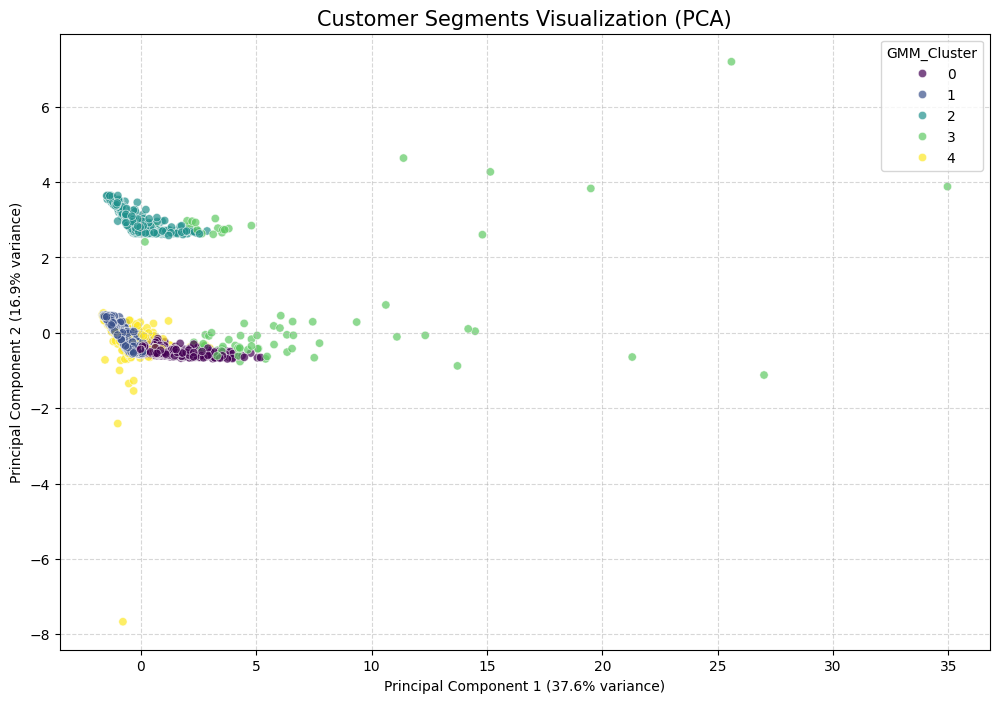

In [18]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled) 

rfm_expanded['PCA1'] = pca_data[:, 0]
rfm_expanded['PCA2'] = pca_data[:, 1]

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x="PCA1", y="PCA2",
    hue="GMM_Cluster", 
    palette="viridis",
    data=rfm_expanded,
    legend="full",
    alpha=0.7
)

plt.title('Customer Segments Visualization (PCA)', fontsize=15)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [19]:
features_to_use = ['Recency', 'Frequency', 'Monetary', 'Variety', 'Avg_Quantity', 'Tenure'] 

loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=features_to_use)
print("The impact of each feature on the new axes:")
print(loadings)


The impact of each feature on the new axes:
                   PC1       PC2
Recency      -0.308010  0.274731
Frequency     0.593073 -0.011860
Monetary      0.485429  0.147597
Variety       0.561949 -0.039259
Avg_Quantity -0.003972 -0.121722
Tenure        0.044172  0.941403


In [20]:
variety_col = 'Product_Variety' 

target_column = 'GMM_Cluster'

validation_df = rfm_expanded.groupby(target_column).agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    variety_col: 'mean' 
}).sort_values('Monetary', ascending=False)


display(validation_df)


,Recency,Frequency,Monetary,Product_Variety
GMM_Cluster,,,,
3,6.850000,47.000000,35900.429125,290.175000
4,119.632867,5.038462,2441.434304,26.150350
0,27.442662,8.522855,2440.276680,120.874098
2,98.902743,3.907731,1626.027756,55.957606
1,124.591179,2.033079,438.812181,27.036896


In [21]:
actual_cluster_col = 'GMM_Cluster' 

df_clean['Segment'] = df_clean['CustomerID'].map(rfm_expanded[actual_cluster_col])

country_segments = pd.crosstab(df_clean['Country'], df_clean['Segment'], normalize='index') * 100

top_countries = df_clean[df_clean['Country'] != 'United Kingdom']['Country'].value_counts().head(10).index
display(country_segments.loc[top_countries])

Segment,0,1,2,3,4
Country,,,,,
Germany,0.0,0.0,72.859400,27.140600,0.0
France,0.0,0.0,80.979861,19.020139,0.0
EIRE,0.0,0.0,2.164329,97.835671,0.0
Spain,0.0,0.0,79.707856,20.292144,0.0
Netherlands,0.0,0.0,12.062421,87.937579,0.0
Belgium,0.0,0.0,100.000000,0.000000,0.0
Switzerland,0.0,0.0,100.000000,0.000000,0.0
Portugal,0.0,0.0,100.000000,0.000000,0.0
Australia,0.0,0.0,38.204925,61.795075,0.0


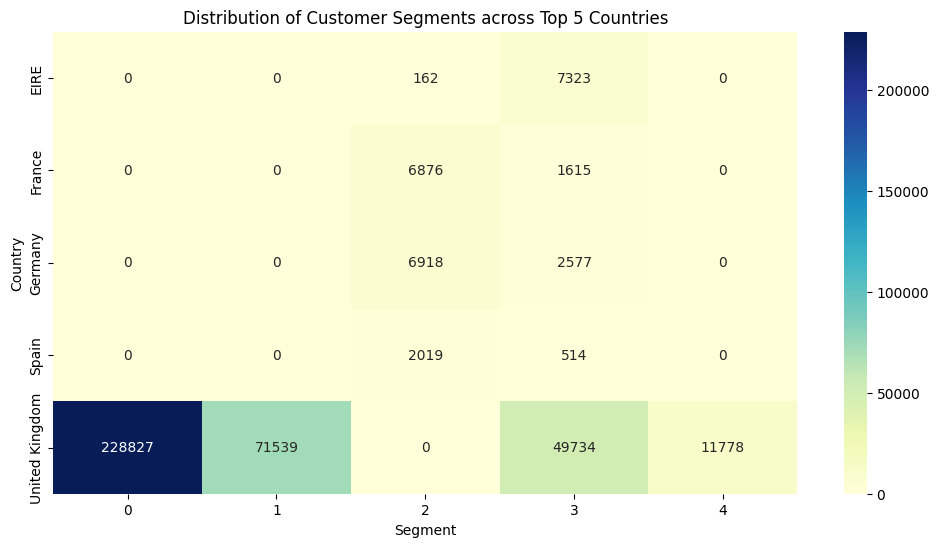

In [22]:
plt.figure(figsize=(12, 6))
top_5_countries = df_clean['Country'].value_counts().head(5).index
df_subset = df_clean[df_clean['Country'].isin(top_5_countries)]

ct = pd.crosstab(df_subset['Country'], df_subset['Segment'])
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Distribution of Customer Segments across Top 5 Countries')
plt.show()

In [23]:
from collections import Counter

def get_top_products(segment_name, top_n=5):
    products = df_clean[df_clean['Segment'] == segment_name]['Description'].str.upper().str.cat(sep=' ')
    words = [word for word in products.split() if len(word) > 3] # كلمات أكتر من 3 حروف لتجنب الـ stop words
    return Counter(words).most_common(top_n)

print("أMost frequently repeated words in Champions' purchases:", get_top_products('Champions 🏆'))
print("The most frequently used words in wholesale purchases:", get_top_products('Wholesale/Bulk 📦'))

أMost frequently repeated words in Champions' purchases: []
The most frequently used words in wholesale purchases: []


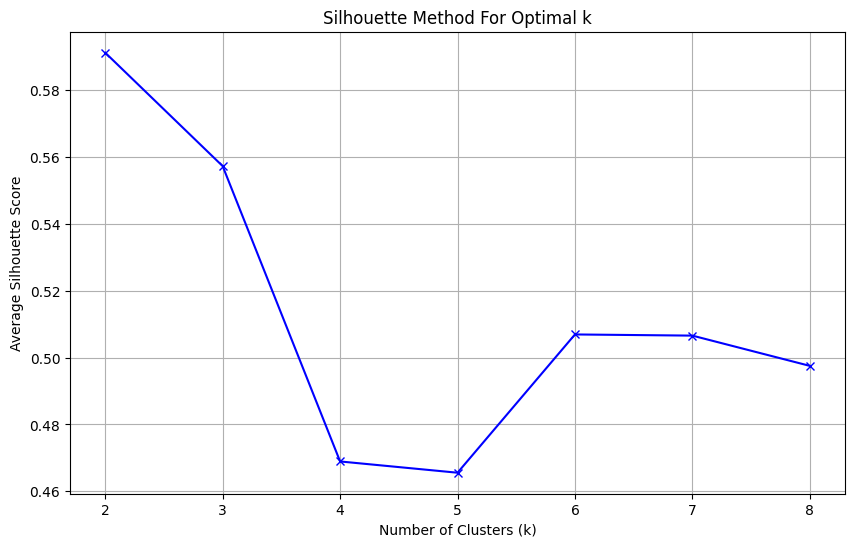

For n_clusters = 2, Silhouette Score is: 0.5912
For n_clusters = 3, Silhouette Score is: 0.5573
For n_clusters = 4, Silhouette Score is: 0.4689
For n_clusters = 5, Silhouette Score is: 0.4655
For n_clusters = 6, Silhouette Score is: 0.5069
For n_clusters = 7, Silhouette Score is: 0.5066
For n_clusters = 8, Silhouette Score is: 0.4975


In [24]:
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]
silhouette_avg = []

for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10)
    cluster_labels = clusterer.fit_predict(X_scaled) 
    
    silhouette_avg.append(silhouette_score(X_scaled, cluster_labels))

plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, silhouette_avg, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.title('Silhouette Method For Optimal k')
plt.grid(True)
plt.show()

for n, score in zip(range_n_clusters, silhouette_avg):
    print(f"For n_clusters = {n}, Silhouette Score is: {score:.4f}")

In [25]:
current_score = silhouette_score(X_scaled, rfm_expanded['Cluster'])
print(f"The final Silhouette Score for the current clustering is: {current_score:.3f}")

The final Silhouette Score for the current clustering is: 0.501
